正在读取全市场数据，请稍候...
正在过滤主板数据...
正在计算 MACD 指标与金叉/死叉信号...
开始按日执行【胜率自适应 + 马丁格尔倍投 + LIFO批次管理】策略模拟，请耐心等待...
已回测 0/3935 个交易日...
已回测 500/3935 个交易日...
已回测 1000/3935 个交易日...
已回测 1500/3935 个交易日...
已回测 2000/3935 个交易日...
已回测 2500/3935 个交易日...
已回测 3000/3935 个交易日...
已回测 3500/3935 个交易日...

✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\data\data\MACD胜率自适应策略明细.xlsx
💰 初始本金: 50,000.00 元
💰 高级自适应最终总资产: 111,377.08 元
📈 策略总收益率: 122.75%


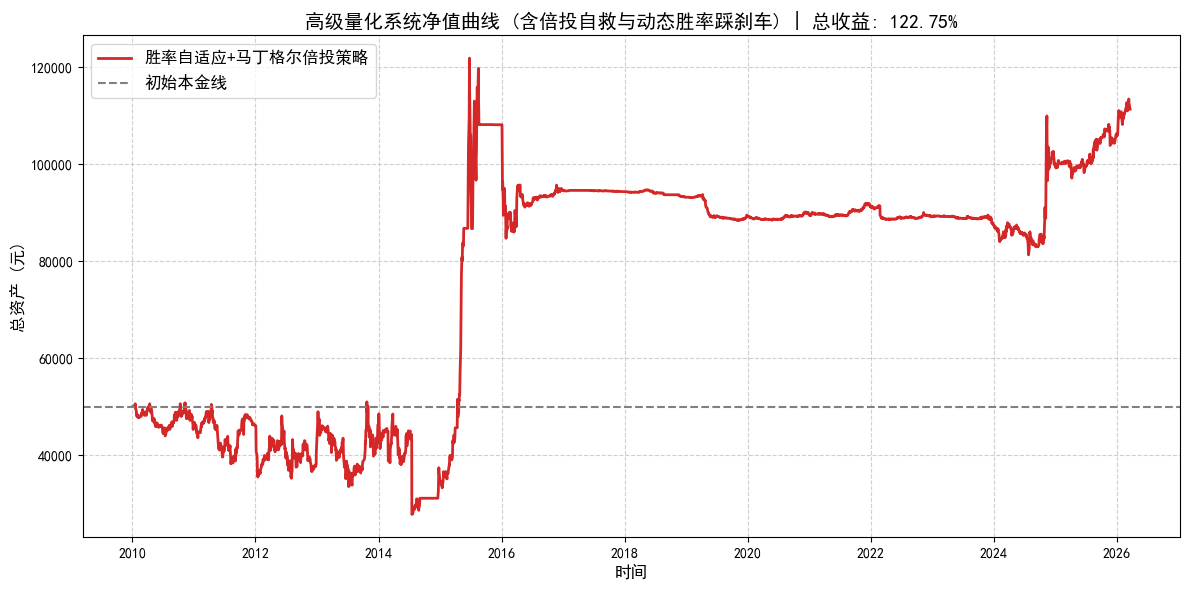

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\MACD胜率自适应策略明细.xlsx"

INITIAL_CASH = 50000.0
# 为了给倍投留有余地，我们将首仓基础金额降低为 3000 元 (基数越小，能撑得倍投次数越多)
BASE_TRADE_AMOUNT = 3000.0

# 新增自适应参数
WIN_RATE_WINDOW = 20      # 统计最近 20 次死叉信号的胜率
WIN_RATE_THRESHOLD = 0.5  # 胜率阈值：>=50% 视为行情好，<50% 视为行情差

print("正在读取全市场数据，请稍候...")
# 用 parquet 读取，几百万行数据通常只需几秒钟
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票 (上交所 60 开头，深交所 00 开头)
print("正在过滤主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 第二步：向量化预计算 MACD 及买卖信号 (极速计算)
# ==========================================
print("正在计算 MACD 指标与金叉/死叉信号...")
df.sort_values(by=['code', 'date'], inplace=True)

# 1. 计算 MACD (参数 12, 26, 9)
df['EMA12'] = df.groupby('code')['close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
df['EMA26'] = df.groupby('code')['close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df['DIF'] = df['EMA12'] - df['EMA26']
df['DEA'] = df.groupby('code')['DIF'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
df['MACD'] = (df['DIF'] - df['DEA']) * 2

# 2. 判断金叉与死叉
df['prev_DIF'] = df.groupby('code')['DIF'].shift(1)
df['prev_DEA'] = df.groupby('code')['DEA'].shift(1)

# 金叉：今天 DIF > DEA 且 昨天 DIF <= DEA
df['GC'] = (df['DIF'] > df['DEA']) & (df['prev_DIF'] <= df['prev_DEA'])
# 死叉：今天 DIF < DEA 且 昨天 DIF >= DEA
df['DC'] = (df['DIF'] < df['DEA']) & (df['prev_DIF'] >= df['prev_DEA'])

# 3. 记录上一次金叉时的位置 (水上还是水下)
# 把所有发生金叉当天的 DIF 值提取出来，非金叉日设为 NaN
df['GC_DIF_Value'] = np.where(df['GC'], df['DIF'], np.nan)
# 向下填充，并 shift(1)，这样今天就能知道“上一次金叉的 DIF 值是多少”
df['prev_GC_DIF'] = df.groupby('code')['GC_DIF_Value'].transform(lambda x: x.ffill().shift(1))

# 4. 生成核心买卖信号
# 买入信号基础：今天发生金叉 & 今天是水上(DIF>0) & 上一次金叉是水下(prev_GC_DIF<0)
# 这个信号作为首仓买入点，或作为被套后的加仓点
df['Buy_Signal'] = df['GC'] & (df['DIF'] > 0) & (df['prev_GC_DIF'] < 0)
# 卖出信号判定点：死叉
df['Sell_Signal'] = df['DC']

# ==========================================
# 第三步：定义带胜率追踪的批次账户类 (核心重构)
# ==========================================
def calculate_fees(trade_type, price, volume):
    """
    计算交易费用：佣金万2.5最低5元+过户费10万分之1双向+印花税万5卖出
    """
    amount = price * volume
    # 1. 佣金 (最低5元)
    commission = max(5.0, amount * 0.00025)
    # 2. 过户费
    transfer_fee = amount * 0.00001
    # 3. 印花税 (仅卖出收取)
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0

    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        # positions 结构: {code: {'batches': [{'price': p, 'vol': v, 'date': d}], 'total_vol': V, 'total_cost': C}}
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []
        self.recent_outcomes = []  # 记录最近交易胜负的列表 (1 赢, 0 亏/扛单)

    def add_batch(self, code, price, vol, date):
        if code not in self.positions:
            self.positions[code] = {'batches': [], 'total_vol': 0, 'total_cost': 0}
        self.positions[code]['batches'].append({'price': price, 'vol': vol, 'date': date})
        self.positions[code]['total_vol'] += vol
        self.positions[code]['total_cost'] += price * vol

    def get_avg_cost(self, code):
        pos = self.positions.get(code)
        if not pos or pos['total_vol'] == 0: return 0
        return pos['total_cost'] / pos['total_vol']

    def remove_all(self, code):
        # 整体全平，全额结算
        vol = self.positions[code]['total_vol']
        del self.positions[code]
        return vol

    def remove_last_batch(self, code):
        # 仅平仓最近一个批次
        batch = self.positions[code]['batches'].pop()
        self.positions[code]['total_vol'] -= batch['vol']
        self.positions[code]['total_cost'] -= batch['price'] * batch['vol']
        if len(self.positions[code]['batches']) == 0:
            del self.positions[code]
        return batch

    def record_outcome(self, is_win):
        self.recent_outcomes.append(is_win)
        # 只保留最近 20 次记录，计算滚动胜率
        if len(self.recent_outcomes) > WIN_RATE_WINDOW:
            self.recent_outcomes.pop(0)

    def get_win_rate(self):
        if len(self.recent_outcomes) == 0:
            return 1.0  # 初始默认胜率 100%，允许自由交易
        return sum(self.recent_outcomes) / len(self.recent_outcomes)

    def get_total_asset(self, current_prices_dict):
        # 计算总资产 = 现金 + 持仓股票总市值
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['total_vol'] * current_prices_dict.get(code, pos['batches'][-1]['price'])
        return self.cash + stock_value

account = Account(INITIAL_CASH)

# ==========================================
# 第四步：按日执行交易主引擎 (引入胜率控制和倍投逻辑)
# ==========================================
print("开始按日执行【胜率自适应 + 马丁格尔倍投 + LIFO批次管理】策略模拟，请耐心等待...")

# 按照日期分组，比每次过滤要快很多
grouped = df.groupby('date')
dates = sorted(list(grouped.groups.keys()))
total_days = len(dates)

for i, date in enumerate(dates):
    daily_data = grouped.get_group(date).set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    # 记录每日总资产
    current_asset = account.get_total_asset(current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    if i % 500 == 0:
        print(f"已回测 {i}/{total_days} 个交易日...")

    # 获取当前系统胜率
    current_win_rate = account.get_win_rate()

    # ---------------- 1. 卖出与胜率记录逻辑 (死叉判定) ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        # 如果当天该股死叉信号触发
        if code in daily_data.index and daily_data.loc[code, 'Sell_Signal']:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            # 必须正常交易且未跌停
            if is_trading and pct_chg > -9.8:
                current_price = current_prices[code]
                avg_cost = account.get_avg_cost(code)

                # 预留千分之三的费用空间判定“是否真盈利”
                if current_price > avg_cost * 1.003:
                    # 情况A：整体盈利，清仓所有持仓
                    sell_vol = account.remove_all(code)
                    fee, amount = calculate_fees('sell', current_price, sell_vol)
                    account.cash += (amount - fee)

                    account.record_outcome(1) # 记为一次胜利，胜率上升

                    account.trade_logs.append({
                        '日期': date, '股票代码': code, '买卖方向': '卖出(整体止盈)',
                        '成交价': current_price, '成交股数': sell_vol,
                        '成交金额': round(amount, 2), '可用现金': round(account.cash, 2),
                        '系统胜率': f"{account.get_win_rate():.0%}",
                        '备注': '死叉整体盈利，清仓所有批次'
                    })
                else:
                    # 情况B：整体亏损。不平全仓，只看最近加仓的游击队赚没赚钱 (LIFO)
                    last_batch = account.positions[code]['batches'][-1]
                    if current_price > last_batch['price'] * 1.003:
                        # 仅卖出最近一个盈利的批次
                        removed_batch = account.remove_last_batch(code)
                        sell_vol = removed_batch['vol']
                        fee, amount = calculate_fees('sell', current_price, sell_vol)
                        account.cash += (amount - fee)

                        # 虽然部分盈利，但整体仍亏损，在系统里记为 0 (胜率下降)
                        account.record_outcome(0)

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '卖出(加仓批次止盈)',
                            '成交价': current_price, '成交股数': sell_vol,
                            '成交金额': round(amount, 2), '可用现金': round(account.cash, 2),
                            '系统胜率': f"{account.get_win_rate():.0%}",
                            '备注': '死叉整体浮亏，仅平仓盈利批次'
                        })
                    else:
                        # 情况C：整体亏损，且加仓批次也亏损。死扛，系统里记为 0 (胜率下降)
                        account.record_outcome(0)

    # ---------------- 2. 买入/加仓逻辑 (结合系统胜率与倍投逻辑) ----------------
    buy_candidates = daily_data[
        (daily_data['Buy_Signal'] == True) &
        (daily_data['tradestatus'] == 1) &
        (daily_data['isST'] == 0) &
        (daily_data['pctChg'] < 9.8)
    ].index.tolist()

    # 动态开仓判定：如果胜率达标，或者目前完全空仓，则允许开启新股建仓。
    can_open_new = (current_win_rate >= WIN_RATE_THRESHOLD) or (len(account.positions) == 0)

    for code in buy_candidates:
        current_price = current_prices[code]
        execute_buy = False
        is_add_position = False
        memo = ''

        # 判定这次买入属于“建仓”还是“被套加仓”
        if code in account.positions:
            # 已经在持仓中，如果未盈利，触发马丁格尔加仓
            avg_cost = account.get_avg_cost(code)
            if current_price < avg_cost:
                execute_buy = True
                is_add_position = True
        else:
            # 之前没这只股，属于开新仓
            if can_open_new:
                # 只有胜率行情好，或者被逼到墙角才开新股
                execute_buy = True

        if execute_buy:
            # 【核心逻辑】动态计算投入金额 (马丁格尔倍投：1、2、4、8倍投)
            if not is_add_position:
                # 首仓：3000 元基础金额
                target_cash = min(BASE_TRADE_AMOUNT, account.cash)
                memo = '首仓买入(多头扩张)'
            else:
                # 加仓：计算倍投金额。如果有1个批次，买入基数的2倍；有2个批次，买基数4倍...
                current_batches_count = len(account.positions[code]['batches'])
                # 防止由于跌停无法卖出导致的无限倍投，限制单只股票最多加仓 3 次 (即撑死买 1+2+4+8 倍基数)
                if current_batches_count > 3: continue

                # 倍数 = 2^(当前批次数)。首仓后第1次买基数2倍，第2次买4倍
                multiplier = 2 ** current_batches_count
                target_cash = min(BASE_TRADE_AMOUNT * multiplier, account.cash)
                memo = f'金叉加仓自救({multiplier}倍投)'

            affordable_shares = int((target_cash * 0.997) / current_price)
            buy_vol = (affordable_shares // 100) * 100

            if buy_vol >= 100:
                fee, amount = calculate_fees('buy', current_price, buy_vol)

                # 现金流确认：必须现金足够支付本金和费用
                if account.cash >= (amount + fee):
                    account.cash -= (amount + fee)
                    account.add_batch(code, current_price, buy_vol, date)

                    account.trade_logs.append({
                        '日期': date, '股票代码': code, '买卖方向': '买入' if not is_add_position else '加仓',
                        '成交价': current_price, '成交股数': buy_vol,
                        '成交金额': round(amount, 2), '可用现金': round(account.cash, 2),
                        '系统胜率': f"{account.get_win_rate():.0%}",
                        '备注': memo
                    })

# ==========================================
# 第五步：输出结果与可视化
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 高级自适应最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

# 绘制资金曲线
plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#d62728', linewidth=2, label='胜率自适应+马丁格尔倍投策略')
plt.title(f'高级量化系统净值曲线 (含倍投自救与动态胜率踩刹车) | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金线')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()